<a href="https://colab.research.google.com/github/Timmythaw/langgraph-adk-edu-comparison/blob/main/notebooks/01_langgraph_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Setup

#### Install Dependencies

In [1]:
!pip install langgraph langchain-google-vertexai langchain-google-community \
    google-cloud-aiplatform google-cloud-discoveryengine \
    google-api-python-client google-auth-httplib2 google-auth-oauthlib -q
!pip show langgraph

Name: langgraph
Version: 1.1.2
Summary: Building stateful, multi-actor applications with LLMs
Home-page: https://docs.langchain.com/oss/python/langgraph/overview
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph-checkpoint, langgraph-prebuilt, langgraph-sdk, pydantic, xxhash
Required-by: langchain, langchain-google-community


#### Load Secrets

In [2]:
from google.colab import userdata

PROJECT_ID   = userdata.get("GOOGLE_CLOUD_PROJECT")
LOCATION     = userdata.get("GOOGLE_CLOUD_LOCATION")
DATASTORE_ID = userdata.get("VERTEX_AI_SEARCH_DATASTORE_ID")

print("Project:",   PROJECT_ID)
print("Location:",  LOCATION)
print("Datastore:", DATASTORE_ID)

Project: edu-teacher-assistant-prod
Location: global
Datastore: curriculum-connector_1765189225594_gcs_store


#### Google Authentication

In [3]:
from google.colab import auth
auth.authenticate_user()

import google.auth
credentials, project = google.auth.default()
print("Authenticated")
print("Project:", project)

Authenticated
Project: 


#### Set Project and Verify

In [4]:
import os
import vertexai
from google.cloud import aiplatform

os.environ["GOOGLE_CLOUD_PROJECT"]  = PROJECT_ID
os.environ["GOOGLE_CLOUD_LOCATION"] = LOCATION

vertexai.init(project=PROJECT_ID, location="us-central1")
aiplatform.init(project=PROJECT_ID, location="us-central1")

print("Project:",  PROJECT_ID)
print("Search Location:", LOCATION)
print("Datastore:", DATASTORE_ID)
print("Vertex AI backend enabled for LangGraph")

Project: edu-teacher-assistant-prod
Search Location: global
Datastore: curriculum-connector_1765189225594_gcs_store
Vertex AI backend enabled for LangGraph


#### LangGraph Import & Version

In [5]:
from importlib.metadata import version
print("LangGraph version:", version("langgraph"))

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_google_vertexai import ChatVertexAI
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, Annotated, Literal
import operator

print("All LangGraph imports successful")

LangGraph version: 1.1.2
All LangGraph imports successful


# Sub Nodes

#### Tool: Vertex AI Search

In [6]:
from google.cloud import discoveryengine_v1 as discoveryengine

def retrieve_course_materials(query: str) -> str:
    client = discoveryengine.SearchServiceClient()

    serving_config = (
        f"projects/{PROJECT_ID}/locations/{LOCATION}"
        f"/collections/default_collection/dataStores/{DATASTORE_ID}"
        f"/servingConfigs/default_config"
    )

    request = discoveryengine.SearchRequest(
        serving_config=serving_config,
        query=query,
        page_size=3,
        content_search_spec=discoveryengine.SearchRequest.ContentSearchSpec(
            snippet_spec=discoveryengine.SearchRequest.ContentSearchSpec.SnippetSpec(
                return_snippet=True
            ),
            summary_spec=discoveryengine.SearchRequest.ContentSearchSpec.SummarySpec(
                summary_result_count=3,
                include_citations=True,
            )
        ),
    )

    response = client.search(request)
    snippets = []
    for result in response.results:
        doc = result.document
        if doc.derived_struct_data:
            for snippet in doc.derived_struct_data.get("snippets", []):
                snippets.append(snippet.get("snippet", ""))

    return "\n\n---\n\n".join(snippets) if snippets else "No relevant materials found."

# Test it
result = retrieve_course_materials("software testing lesson plan")
print(result)

Here is a 7-week <b>lesson plan</b> for a <b>Software Testing</b> course, designed for university second-year second-semester students. It incorporates a mixed teaching&nbsp;...

---

<b>Software Testing</b> There are two major types of <b>software testing</b> - Black box testing : focuses on input, output, and principle function of a software module. -&nbsp;...


#### State Schema

In [7]:
from typing import TypedDict, Annotated
import operator

class TeacherState(TypedDict):
    messages:        Annotated[list, operator.add]   # conversation history
    task_type:       str                              # "lesson_plan" | "quiz" | "email"
    course_materials: str                             # RAG retrieval result
    draft_output:    str                              # intermediate draft (email / quiz JSON)
    final_output:    str                              # final formatted response
    hitl_decision:   str                              # "approved" | "rejected" | ""

print("State schema defined")

State schema defined


#### Models

In [8]:
orchestrator_llm = ChatVertexAI(model_name="gemini-2.5-pro",  project=PROJECT_ID, location="us-central1")
worker_llm       = ChatVertexAI(model_name="gemini-2.5-flash", project=PROJECT_ID, location="us-central1")
print("Models initialised")

Models initialised


/tmp/ipykernel_18188/1381402949.py:1: DeprecationWarning: Use [`ChatGoogleGenerativeAI`][langchain_google_genai.ChatGoogleGenerativeAI] instead.
  orchestrator_llm = ChatVertexAI(model_name="gemini-2.5-pro",  project=PROJECT_ID, location="us-central1")
/tmp/ipykernel_18188/1381402949.py:1: LangChainDeprecationWarning: The class `ChatVertexAI` was deprecated in LangChain 3.2.0 and will be removed in 4.0.0. An updated version of the class exists in the `langchain-google-genai package and should be used instead. To use it run `pip install -U `langchain-google-genai` and import as `from `langchain_google_genai import ChatGoogleGenerativeAI``.
  orchestrator_llm = ChatVertexAI(model_name="gemini-2.5-pro",  project=PROJECT_ID, location="us-central1")
/tmp/ipykernel_18188/1381402949.py:2: DeprecationWarning: Use [`ChatGoogleGenerativeAI`][langchain_google_genai.ChatGoogleGenerativeAI] instead.
  worker_llm       = ChatVertexAI(model_name="gemini-2.5-flash", project=PROJECT_ID, location="us-ce

#### Router Node

In [9]:
def router_node(state: TeacherState) -> TeacherState:
    """
    Two-stage router:
    1. Fast keyword match — EMAIL checked first (highest specificity)
    2. LLM fallback via orchestrator_llm if keywords don't match
    """
    user_msg = state["messages"][-1].content
    lower    = user_msg.lower()

    # Stage 1: fast keyword match — ORDER MATTERS: email first
    if any(k in lower for k in ["email", "send", "announcement", "draft"]):
        task = "email"
    elif any(k in lower for k in ["lesson plan", "outline", "lecture"]):
        task = "lesson_plan"
    elif any(k in lower for k in ["quiz", "multiple choice", "question", "mcq"]):
        task = "quiz"
    else:
        # Stage 2: LLM orchestrator reasoning fallback
        prompt = (
            "You are a task classifier for an AI Teaching Assistant.\n"
            "Classify the instructor's request into exactly one of these tasks:\n"
            "  - lesson_plan : creating a lesson plan, course outline, or lecture notes\n"
            "  - quiz        : generating quiz questions or assessments\n"
            "  - email       : drafting or sending a message/announcement to students\n\n"
            f"Instructor request: {user_msg}\n\n"
            "Reply with ONLY the task name (lesson_plan / quiz / email). No explanation."
        )
        llm_reply = orchestrator_llm.invoke([HumanMessage(content=prompt)]).content.strip().lower()
        task = llm_reply if llm_reply in {"lesson_plan", "quiz", "email"} else "lesson_plan"
        print(f"[Router] Keyword miss → LLM classified as: '{task}' (raw: '{llm_reply}')")

    print(f"[Router] task_type = {task}")
    return {**state, "task_type": task}


def route_to_agent(state: TeacherState) -> Literal["lesson_planner", "quiz_content", "email_drafter"]:
    return {"lesson_plan": "lesson_planner",
            "quiz":        "quiz_content",
            "email":       "email_drafter"}[state["task_type"]]


print("Router defined (keyword + LLM fallback)")

Router defined (keyword + LLM fallback)


#### Lesson Planner Node

In [10]:
def lesson_planner_node(state: TeacherState) -> TeacherState:
    user_query = state["messages"][-1].content
    materials  = retrieve_course_materials(user_query)

    prompt = f"""You are an expert curriculum designer at Mae Fah Luang University.

Course Materials:
{materials}

Instructor Request:
{user_query}

Generate a comprehensive 90-minute lesson plan that includes:
- Learning Objectives
- Duration and timing breakdown
- Teaching methods and student activities
- Assessment strategy
- Required materials

Always ground your lesson plan in the retrieved course materials."""

    response = worker_llm.invoke([HumanMessage(content=prompt)])
    return {**state,
            "course_materials": materials,
            "final_output":     response.content,
            "messages":         [AIMessage(content=response.content)]}

print("Lesson Planner node defined")

Lesson Planner node defined


#### Quiz Content Node (retrieves + generates JSON)

In [11]:
def quiz_content_node(state: TeacherState) -> TeacherState:
    user_query = state["messages"][0].content
    materials  = retrieve_course_materials(user_query)

    prompt = f"""You are a quiz content specialist at Mae Fah Luang University.

Course Materials:
{materials}

Topic: {user_query}

Generate exactly 10 multiple-choice questions.
Format your ENTIRE response as a valid JSON array only. No text outside the JSON.

Each question:
[
  {{
    "question": "question text",
    "options": ["A. option1", "B. option2", "C. option3", "D. option4"],
    "correct_index": 0,
    "explanation": "why this is correct"
  }}
]"""

    response = worker_llm.invoke([HumanMessage(content=prompt)])
    return {**state,
            "course_materials": materials,
            "draft_output":     response.content}

print("Quiz Content node defined")

Quiz Content node defined


#### Quiz Publisher Node (formats + presents)

In [12]:
def quiz_publisher_node(state: TeacherState) -> TeacherState:
    quiz_json = state["draft_output"]

    prompt = f"""You are a quiz publisher.

The quiz questions JSON is:
{quiz_json}

Parse the JSON and present the quiz in a clean, readable format:
- Number each question
- List all 4 options with A/B/C/D labels
- Mark the correct answer with ✅
- Include the explanation

Present all 10 questions clearly."""

    response = worker_llm.invoke([HumanMessage(content=prompt)])
    return {**state,
            "final_output": response.content,
            "messages":     [AIMessage(content=response.content)]}

print("Quiz Publisher node defined")

Quiz Publisher node defined


#### Email Drafter Node

In [13]:
def email_drafter_node(state: TeacherState) -> TeacherState:
    user_query = state["messages"][0].content

    prompt = f"""You are a professional email drafting assistant for a university lecturer at Mae Fah Luang University.

Draft a professional email to students based on the instructor's request:
{user_query}

Format your response EXACTLY as:
SUBJECT: [subject line]
BODY:
[email body]

Use formal university tone."""

    response = worker_llm.invoke([HumanMessage(content=prompt)])
    return {**state, "draft_output": response.content}

print("Email Drafter node defined")

Email Drafter node defined


#### HITL Node — Stateful Interrupt (instructor can edit draft)

In [14]:
def hitl_approval_node(state: TeacherState) -> TeacherState:
    draft = state["draft_output"]

    print("\n" + "="*50)
    print("INSTRUCTOR APPROVAL REQUIRED")
    print("="*50)
    print(draft)
    print("="*50)
    print("Options: 'yes' to approve | 'no' to reject | paste edited draft to approve with edits")

    decision = input("\nApprove and send this email? (yes/no/edit): ").strip()

    if decision.lower() == "yes":
        return {**state, "hitl_decision": "approved"}
    elif decision.lower() == "no":
        return {**state, "hitl_decision": "rejected"}
    else:
        return {**state, "draft_output": decision, "hitl_decision": "approved"}

print("HITL node defined")

HITL node defined


#### Email Sender Node

In [15]:
def email_sender_node(state: TeacherState) -> TeacherState:
    if state["hitl_decision"] == "approved":
        msg = f"Email approved and sent to students.\n\n{state['draft_output']}"
    else:
        msg = f"Email rejected by instructor. Not sent.\n\nDraft was:\n{state['draft_output']}"

    return {**state,
            "final_output": msg,
            "messages":     [AIMessage(content=msg)]}


def route_after_hitl(state: TeacherState) -> Literal["email_sender", "email_drafter"]:
    return "email_sender"   # always go to sender — it handles both approved/rejected

print("Email Sender node defined")

Email Sender node defined


# Graph Assembly

In [16]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

builder = StateGraph(TeacherState)

# Add nodes
builder.add_node("router",          router_node)
builder.add_node("lesson_planner",  lesson_planner_node)
builder.add_node("quiz_content",    quiz_content_node)
builder.add_node("quiz_publisher",  quiz_publisher_node)
builder.add_node("email_drafter",   email_drafter_node)
builder.add_node("hitl_approval",   hitl_approval_node)
builder.add_node("email_sender",    email_sender_node)

# Entry
builder.set_entry_point("router")

# Routing from router
builder.add_conditional_edges("router", route_to_agent)

# Lesson plan -> END
builder.add_edge("lesson_planner", END)

# Quiz pipeline
builder.add_edge("quiz_content",   "quiz_publisher")
builder.add_edge("quiz_publisher", END)

# Email pipeline with HITL
builder.add_edge("email_drafter",  "hitl_approval")
builder.add_conditional_edges("hitl_approval", route_after_hitl)
builder.add_edge("email_sender",   END)

graph = builder.compile(checkpointer=checkpointer)
print("Graph compiled successfully")
print("Nodes:", list(graph.get_graph().nodes.keys()))

Graph compiled successfully
Nodes: ['__start__', 'router', 'lesson_planner', 'quiz_content', 'quiz_publisher', 'email_drafter', 'hitl_approval', 'email_sender', '__end__']


# Runner SetUP

In [17]:
import uuid, time

APP_NAME = "teacher_assistant_langgraph"
USER_ID  = "mfu_instructor_01"

def run_request(user_input: str, hitl_decision: str = None) -> tuple[str, float]:
    thread_id = str(uuid.uuid4())
    config    = {"configurable": {"thread_id": thread_id}}
    init_state = {
        "messages":          [HumanMessage(content=user_input)],
        "task_type":         "",
        "course_materials":  "",
        "draft_output":      "",
        "final_output":      "",
        "hitl_decision":     "",
    }

    start  = time.time()
    result = graph.invoke(init_state, config)  # always runs straight through
    latency = round(time.time() - start, 2)
    return result.get("final_output", ""), latency

print("Runner ready")
print("  App:", APP_NAME)
print("  User:", USER_ID)

Runner ready
  App: teacher_assistant_langgraph
  User: mfu_instructor_01


# Metrics Logger

In [18]:
import csv, os
from datetime import datetime, timezone

METRICS_FILE = "langgraph_metrics.csv"
FIELDNAMES = [
    "timestamp", "scenario", "framework", "routing_correct",
    "latency_sec", "response_length", "error"
]

def log_metric(scenario: str, routing_correct: bool, latency: float, response: str, error: str = ""):
    write_header = not os.path.exists(METRICS_FILE)
    with open(METRICS_FILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        if write_header:
            writer.writeheader()
        writer.writerow({
            "timestamp":      datetime.now(timezone.utc).isoformat(),
            "scenario":       scenario,
            "framework":      "LangGraph",
            "routing_correct": routing_correct,
            "latency_sec":    latency,
            "response_length": len(response),
            "error":          error
        })
    print(f"Logged: {scenario} | latency={latency}s | routing={routing_correct}")

print("Metrics logger ready")

Metrics logger ready


# Scenario 1: Lesson Plan Generation

In [19]:
SCENARIO_1_PROMPT = "Create a 90-minute lesson plan on Software Testing for second-year Software Engineering students. Align it with the course materials."

print("Running Scenario 1 - Lesson Plan Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, latency = run_request(SCENARIO_1_PROMPT)
        routing_correct = "lesson plan" in response.lower() or "learning objectives" in response.lower()
        log_metric("Scenario 1 - Lesson Plan", routing_correct, latency, response)
        print(f"  Latency: {latency}s | Routing: {routing_correct} | Length: {len(response)} chars")
    except Exception as e:
        log_metric("Scenario 1 - Lesson Plan", False, 0, "", str(e))
        print(f"  Error: {e}")

print("\nScenario 1 complete.")

Running Scenario 1 - Lesson Plan Generation (5 runs)
------------------------------------------------------------

Run 1/5...
[Router] task_type = lesson_plan
Logged: Scenario 1 - Lesson Plan | latency=21.67s | routing=True
  Latency: 21.67s | Routing: True | Length: 7736 chars

Run 2/5...
[Router] task_type = lesson_plan
Logged: Scenario 1 - Lesson Plan | latency=26.34s | routing=True
  Latency: 26.34s | Routing: True | Length: 9623 chars

Run 3/5...
[Router] task_type = lesson_plan
Logged: Scenario 1 - Lesson Plan | latency=26.47s | routing=True
  Latency: 26.47s | Routing: True | Length: 7581 chars

Run 4/5...
[Router] task_type = lesson_plan
Logged: Scenario 1 - Lesson Plan | latency=24.63s | routing=True
  Latency: 24.63s | Routing: True | Length: 9617 chars

Run 5/5...
[Router] task_type = lesson_plan
Logged: Scenario 1 - Lesson Plan | latency=20.84s | routing=True
  Latency: 20.84s | Routing: True | Length: 6874 chars

Scenario 1 complete.


# Scenario 2: Quiz Generator

In [20]:
SCENARIO_2_PROMPT = "Generate 10 multiple-choice questions on Software Testing from the course materials."

print("Running Scenario 2 - Quiz Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, latency = run_request(SCENARIO_2_PROMPT)
        routing_correct = "question" in response.lower() or "quiz" in response.lower()
        log_metric("Scenario 2 - Quiz Generation", routing_correct, latency, response)
        print(f"  Latency: {latency}s | Routing: {routing_correct} | Length: {len(response)} chars")
    except Exception as e:
        log_metric("Scenario 2 - Quiz Generation", False, 0, "", str(e))
        print(f"  Error: {e}")

print("\nScenario 2 complete.")

Running Scenario 2 - Quiz Generation (5 runs)
------------------------------------------------------------

Run 1/5...
[Router] task_type = quiz
Logged: Scenario 2 - Quiz Generation | latency=28.22s | routing=True
  Latency: 28.22s | Routing: True | Length: 4773 chars

Run 2/5...
[Router] task_type = quiz
Logged: Scenario 2 - Quiz Generation | latency=18.5s | routing=True
  Latency: 18.5s | Routing: True | Length: 3701 chars

Run 3/5...
[Router] task_type = quiz
Logged: Scenario 2 - Quiz Generation | latency=17.74s | routing=True
  Latency: 17.74s | Routing: True | Length: 3932 chars

Run 4/5...
[Router] task_type = quiz
Logged: Scenario 2 - Quiz Generation | latency=24.64s | routing=True
  Latency: 24.64s | Routing: True | Length: 4838 chars

Run 5/5...
[Router] task_type = quiz
Logged: Scenario 2 - Quiz Generation | latency=18.94s | routing=True
  Latency: 18.94s | Routing: True | Length: 4084 chars

Scenario 2 complete.


# Scenario 3: Email With HITL

> **Key LangGraph difference:** `interrupt()` pauses graph execution with full state access. The instructor can approve, reject, OR edit the draft in-place before resuming — unlike ADK's binary approve/reject only.

In [21]:
SCENARIO_3_PROMPT = "Draft and send an email to all students reminding them that the SQL Joins quiz is next Monday at 9am. Include what topics to study."

print("Running Scenario 3 - Email with HITL (5 runs)")
print("-" * 60)
print("Note: Each run will pause for your approval input (yes/no)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        response, latency = run_request(SCENARIO_3_PROMPT)
        routing_correct = (
            "email" in response.lower() or
            "approved" in response.lower() or
            "rejected" in response.lower() or
            "not sent" in response.lower()
        )
        log_metric(f"Scenario 3 - Email HITL", routing_correct, latency, response)
        print(f"  Latency: {latency}s | Routing: {routing_correct} | Length: {len(response)} chars")
        print(f"  Response preview: {response[:120]}...")
    except Exception as e:
        log_metric("Scenario 3 - Email HITL", False, 0, "", str(e))
        print(f"  Error: {e}")

print("\nScenario 3 complete.")

Running Scenario 3 - Email with HITL (5 runs)
------------------------------------------------------------
Note: Each run will pause for your approval input (yes/no)
------------------------------------------------------------

Run 1/5...
[Router] task_type = email

INSTRUCTOR APPROVAL REQUIRED
SUBJECT: Reminder: SQL Joins Quiz Next Monday

BODY:
Dear Students,

This email serves as a reminder that our quiz on SQL Joins is scheduled for next Monday, [Insert Next Monday's Date Here], at 9:00 AM. The quiz will be conducted during our regular class time.

To prepare for the quiz, please ensure you review the following topics thoroughly:

*   **Introduction to SQL Joins:** Understanding the concept and purpose of joining tables.
*   **Types of Joins:**
    *   INNER JOIN
    *   LEFT JOIN (LEFT OUTER JOIN)
    *   RIGHT JOIN (RIGHT OUTER JOIN)
    *   FULL JOIN (FULL OUTER JOIN)
    *   Self-Join
*   **Syntax for each Join type.**
*   **Practical application of Joins:** Ability to write qu

# Metrics Summary

In [26]:
import pandas as pd

df = pd.read_csv(METRICS_FILE)

# Keep only the final clean run (last 5 of each scenario)
s1 = df[df['scenario'] == 'Scenario 1 - Lesson Plan'].tail(5)
s2 = df[df['scenario'] == 'Scenario 2 - Quiz Generation'].tail(5)
s3 = df[df['scenario'] == 'Scenario 3 - Email HITL'].tail(5)

df = pd.concat([s1, s2, s3]).reset_index(drop=True)
df.to_csv(METRICS_FILE, index=False)
print(f"Cleaned CSV: {len(df)} runs retained")
print(df.to_string(index=False))

Cleaned CSV: 15 runs retained
                       timestamp                     scenario framework  routing_correct  latency_sec  response_length  error
2026-03-22T09:05:40.711900+00:00     Scenario 1 - Lesson Plan LangGraph             True        21.67             7736    NaN
2026-03-22T09:06:07.053661+00:00     Scenario 1 - Lesson Plan LangGraph             True        26.34             9623    NaN
2026-03-22T09:06:33.524349+00:00     Scenario 1 - Lesson Plan LangGraph             True        26.47             7581    NaN
2026-03-22T09:06:58.156772+00:00     Scenario 1 - Lesson Plan LangGraph             True        24.63             9617    NaN
2026-03-22T09:07:18.995027+00:00     Scenario 1 - Lesson Plan LangGraph             True        20.84             6874    NaN
2026-03-22T09:07:47.232139+00:00 Scenario 2 - Quiz Generation LangGraph             True        28.22             4773    NaN
2026-03-22T09:08:05.728343+00:00 Scenario 2 - Quiz Generation LangGraph             True

# Final Analysis & Report

In [27]:
summary = df.groupby("scenario").agg(
    runs        =("latency_sec", "count"),
    avg_latency =("latency_sec", "mean"),
    min_latency =("latency_sec", "min"),
    max_latency =("latency_sec", "max"),
    routing_accuracy=("routing_correct", "mean")
).round(2)

print("=== LangGraph Experiment Summary ===")
print(summary.to_string())

from google.colab import files
files.download(METRICS_FILE)

=== LangGraph Experiment Summary ===
                              runs  avg_latency  min_latency  max_latency  routing_accuracy
scenario                                                                                   
Scenario 1 - Lesson Plan         5        23.99        20.84        26.47               1.0
Scenario 2 - Quiz Generation     5        21.61        17.74        28.22               1.0
Scenario 3 - Email HITL          5         9.53         5.87        18.26               1.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Latency Visualization

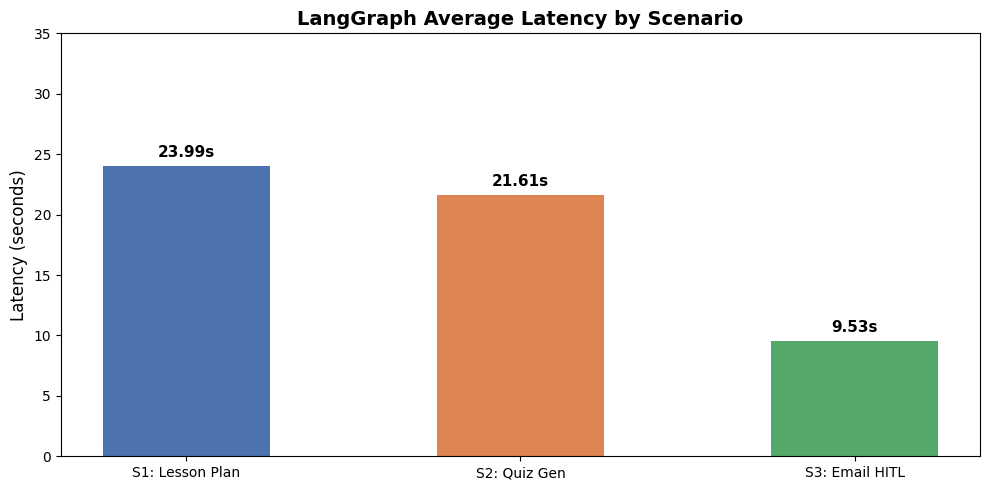

Chart saved.


In [29]:
import matplotlib.pyplot as plt

scenario_labels = [
    "S1: Lesson Plan",
    "S2: Quiz Gen",
    "S3: Email HITL",
]

avg_latencies = summary["avg_latency"].values.tolist()

plt.figure(figsize=(10, 5))
bars = plt.bar(
    scenario_labels,
    avg_latencies,
    color=["#4C72B0", "#DD8452", "#55A868"],
    width=0.5
)

# Add value labels on top of each bar
for bar, val in zip(bars, avg_latencies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.2f}s",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title("LangGraph Average Latency by Scenario", fontsize=14, fontweight='bold')
plt.ylabel("Latency (seconds)", fontsize=12)
plt.ylim(0, 35)
plt.tight_layout()
plt.savefig("langgraph_latency_chart.png", dpi=150)
plt.show()
print("Chart saved.")